In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [16]:
# Defining State
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [18]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

def categorize(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi <= 25:
        state['category'] = 'Normal'
    elif 25 <= bmi <= 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'

    return state
    

In [19]:
# Define your Graph
graph = StateGraph(BMIState)

# Add nodes to the Graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('categorize', categorize)

# Add edges to the Graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'categorize')
graph.add_edge('calculate_bmi', END)

# Compile the Graph
workflow = graph.compile()

In [34]:
# Execute the Graph
initial_state = {'weight_kg': 57, 'height_m':1.70}
final_state = workflow.invoke(initial_state)

In [35]:
print(final_state)

{'weight_kg': 57, 'height_m': 1.7, 'bmi': 19.72, 'category': 'Normal'}


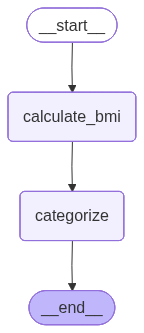

In [36]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())